# Gender Bias Exploration — Random Forest

**Model rationale for ADNI data:**  
Random Forest ensembles 200 decision trees, providing robustness to outliers and capturing non-linear interactions between cognitive, genetic, and imaging features. It's less prone to overfitting than XGBoost on small clinical datasets (n=757). Built-in feature importance enables direct comparison with LIME/SHAP attributions.

Hyperparameters: n_estimators=200, max_depth=6, min_samples_leaf=5.

**6 debiasing methods × 2 imbalance modes = 12 configurations.**

In [25]:
%matplotlib inline
from exploration_utils import *
from IPython.display import display, Markdown

In [26]:
df = load_adni_data()
print('Original shape:', df.shape)
df = drop_metadata(df)
print('After dropping metadata:', df.shape)
display(df.head(2))

Original shape: (757, 147)
After dropping metadata: (757, 129)


,DIAGNOSIS,Sex,age,DXNODEP,DXPARK,DXPDES,DXPCOG,DXPATYP,DXDEP,DXOTHDEM,...,RIGHT_BA36_VOL,RIGHT_BA36_NS,RIGHT_PHC_VOL,RIGHT_PHC_NS,RIGHT_SULCUS_VOL,RIGHT_SULCUS_NS,RIGHT_CA_VOL,RIGHT_CA_NS,RIGHT_HIPP_VOL,RIGHT_HIPP_NS
0,0,0,57.9,0,0,0,0,0,0,0,...,0.099781,12.0,0.040663,7.0,0.017779,18.0,0.094855,20.0,0.153476,20.0
1,0,0,66.4,0,0,0,0,0,0,0,...,0.122244,14.0,0.043713,8.0,0.015407,20.0,0.087257,21.0,0.132635,21.0


In [27]:
dataset = make_bld(df)
dataset_train, dataset_val = split_dataset(dataset)
print(f'Train: {dataset_train.features.shape}, Val: {dataset_val.features.shape}')

m_train = BinaryLabelDatasetMetric(dataset_train,
    unprivileged_groups=UNPRIVILEGED_GROUPS, privileged_groups=PRIVILEGED_GROUPS)
m_val = BinaryLabelDatasetMetric(dataset_val,
    unprivileged_groups=UNPRIVILEGED_GROUPS, privileged_groups=PRIVILEGED_GROUPS)
print(f'Training disparate impact = {m_train.disparate_impact():.4f}')
print(f'Validation disparate impact = {m_val.disparate_impact():.4f}')

Train: (499, 128), Val: (258, 128)
Training disparate impact = 0.8232
Validation disparate impact = 1.1675


---
## Baseline (no debiasing)

**Rationale:** Baseline RF — establishes inherent bias in ensemble tree predictions without any intervention.

In [28]:
res_rf_base_smote = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='None')


  RF | None | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.2674
  Metrics:
  Balanced accuracy = 0.8832
  Average odds difference = -0.0958
  Disparate impact = 0.9487
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0171
  Theil index = 0.0559

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  No significant features (males, baseline)

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  No significant features (males, debiased)

  No significant features (females, debiased)


In [29]:
res_rf_base_cw = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='None')


  RF | None | class_weight

  --- Baseline model ---
  Threshold: 0.3367
  Metrics:
  Balanced accuracy = 0.8811
  Average odds difference = -0.0853
  Disparate impact = 0.9095
  Equal opportunity difference = -0.1290
  Statistical parity difference = -0.0340
  Theil index = 0.0537

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQTOTAL > 0.41: T=81.315, p=0.000000
    FAQMEAL > 0.11: T=32.708, p=0.000000
    FAQSHOP > 0.07: T=17.443, p=0.000001
    FAQFORM > 0.89: T=25.191, p=0.000000
    FAQREM > 0.67: T=15.459, p=0.000001

  Significant (females, baseline):
    FAQTOTAL > 0.41: T=43.395, p=0.000002
    FAQSHOP > 0.07: T=18.523, p=0.000050

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQTOTAL > 0.41: T=81.315, p=0.000000
    FAQMEAL > 0.11: T=32.708, p=0.000000
    FAQSHOP > 0.07: T=17.443, p=0.000001
    FAQFORM > 0.89: T=25.191, p=0.000000
    FAQREM > 0.67: T=15.459, p=0.000001

  Significant (females, 

---
## DisparateImpactRemover (DIR)

**Rationale:** DIR's per-feature percentile repair interacts with tree splits differently than with linear models — each tree sees features with reduced gender-rank correlation.

In [30]:
res_rf_dir_smote = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='DIR')


  RF | DIR | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.2674
  Metrics:
  Balanced accuracy = 0.8832
  Average odds difference = -0.0958
  Disparate impact = 0.9487
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0171
  Theil index = 0.0559
  --- Debiased model (DIR) ---
  Threshold: 0.3169
  Metrics:
  Balanced accuracy = 0.8934
  Average odds difference = -0.0879
  Disparate impact = 0.9860
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0044
  Theil index = 0.0521

  Cases improved by debiasing: 5
     y_true  pred_orig  pred_deb     Sex
14      0.0        1.0       0.0    Male
64      0.0        1.0       0.0  Female
102     0.0        1.0       0.0    Male
176     0.0        1.0       0.0    Male
253     0.0        1.0       0.0  Female

  --- T-tests (baseline) ---

  No significant features (males, baseline)

  No significant features (females, baseline)

  --- T-tests (debiased) --

In [31]:
res_rf_dir_cw = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='DIR')


  RF | DIR | class_weight

  --- Baseline model ---
  Threshold: 0.3367
  Metrics:
  Balanced accuracy = 0.8811
  Average odds difference = -0.0853
  Disparate impact = 0.9095
  Equal opportunity difference = -0.1290
  Statistical parity difference = -0.0340
  Theil index = 0.0537
  --- Debiased model (DIR) ---
  Threshold: 0.3169
  Metrics:
  Balanced accuracy = 0.8916
  Average odds difference = -0.0645
  Disparate impact = 0.9502
  Equal opportunity difference = -0.0968
  Statistical parity difference = -0.0184
  Theil index = 0.0488

  Cases improved by debiasing: 4
     y_true  pred_orig  pred_deb     Sex
64      0.0        1.0       0.0  Female
102     0.0        1.0       0.0    Male
176     0.0        1.0       0.0    Male
242     1.0        0.0       1.0  Female

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQTOTAL > 0.41: T=63.958, p=0.000000
    FAQMEAL > 0.11: T=72.409, p=0.000000
    FAQFORM > 0.89: T=8.600, p=0.000057
    FAQSHOP > 0.07: T=23.486, 

---
## Reweighing

**Rationale:** RF supports sample weights — Reweighing can weight training instances to balance representation per group, which propagates through bootstrap sampling.

In [32]:
res_rf_rw_smote = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='Reweighing')


  RF | Reweighing | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.2674
  Metrics:
  Balanced accuracy = 0.8832
  Average odds difference = -0.0958
  Disparate impact = 0.9487
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0171
  Theil index = 0.0559
  --- Debiased model (Reweighing) ---
  Threshold: 0.2773
  Metrics:
  Balanced accuracy = 0.8857
  Average odds difference = -0.0912
  Disparate impact = 0.9693
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0100
  Theil index = 0.0550

  Cases improved by debiasing: 1
    y_true  pred_orig  pred_deb   Sex
14     0.0        1.0       0.0  Male

  --- T-tests (baseline) ---

  No significant features (males, baseline)

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQGAME > 0.98: T=-8.780, p=0.000050
    GENOTYPE_3/3 <= -0.89: T=8.547, p=0.000060

  Significant (females, debiase

In [33]:
res_rf_rw_cw = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='Reweighing')


  RF | Reweighing | class_weight

  --- Baseline model ---
  Threshold: 0.3367
  Metrics:
  Balanced accuracy = 0.8811
  Average odds difference = -0.0853
  Disparate impact = 0.9095
  Equal opportunity difference = -0.1290
  Statistical parity difference = -0.0340
  Theil index = 0.0537
  --- Debiased model (Reweighing) ---
  Threshold: 0.3466
  Metrics:
  Balanced accuracy = 0.8834
  Average odds difference = -0.0934
  Disparate impact = 0.9159
  Equal opportunity difference = -0.1613
  Statistical parity difference = -0.0298
  Theil index = 0.0545

  Cases improved by debiasing: 4
     y_true  pred_orig  pred_deb     Sex
22      0.0        1.0       0.0    Male
29      0.0        1.0       0.0    Male
64      0.0        1.0       0.0  Female
102     0.0        1.0       0.0    Male

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQTOTAL > 0.41: T=127.620, p=0.000000
    FAQMEAL > 0.11: T=51.892, p=0.000000
    FAQSHOP > 0.07: T=21.361, p=0.000000
    FAQFORM > 

---
## AdversarialDebiasing

**Rationale:** AdversarialDebiasing modifies features pre-training. For tree ensembles, this reduces the correlation structure that trees could exploit to infer gender.

In [34]:
res_rf_ad_smote = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='AdversarialDebiasing')


  RF | AdversarialDebiasing | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.2674
  Metrics:
  Balanced accuracy = 0.8832
  Average odds difference = -0.0958
  Disparate impact = 0.9487
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0171
  Theil index = 0.0559
epoch 0; iter: 0; batch classifier loss: 2.980596; batch adversarial loss: 0.744365
epoch 1; iter: 0; batch classifier loss: 1.894905; batch adversarial loss: 0.814140
epoch 2; iter: 0; batch classifier loss: 0.943890; batch adversarial loss: 0.694460
epoch 3; iter: 0; batch classifier loss: 1.167397; batch adversarial loss: 0.685279
epoch 4; iter: 0; batch classifier loss: 0.863835; batch adversarial loss: 0.693011
epoch 5; iter: 0; batch classifier loss: 0.859303; batch adversarial loss: 0.675584
epoch 6; iter: 0; batch classifier loss: 0.908263; batch adversarial loss: 0.720042
epoch 7; iter: 0; batch classifier loss: 0.664316; batch adversarial loss: 0.722251
ep

In [35]:
res_rf_ad_cw = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='AdversarialDebiasing')


  RF | AdversarialDebiasing | class_weight

  --- Baseline model ---
  Threshold: 0.3367
  Metrics:
  Balanced accuracy = 0.8811
  Average odds difference = -0.0853
  Disparate impact = 0.9095
  Equal opportunity difference = -0.1290
  Statistical parity difference = -0.0340
  Theil index = 0.0537
epoch 0; iter: 0; batch classifier loss: 3.056844; batch adversarial loss: 0.776101
epoch 1; iter: 0; batch classifier loss: 1.399364; batch adversarial loss: 0.736132
epoch 2; iter: 0; batch classifier loss: 1.502724; batch adversarial loss: 0.696930
epoch 3; iter: 0; batch classifier loss: 1.190660; batch adversarial loss: 0.698365
epoch 4; iter: 0; batch classifier loss: 0.793859; batch adversarial loss: 0.726479
epoch 5; iter: 0; batch classifier loss: 0.906635; batch adversarial loss: 0.686503
epoch 6; iter: 0; batch classifier loss: 1.139508; batch adversarial loss: 0.728298
epoch 7; iter: 0; batch classifier loss: 0.902096; batch adversarial loss: 0.712188
epoch 8; iter: 0; batch clas

---
## PrejudiceRemover

**Rationale:** PrejudiceRemover adds fairness regularization during feature transformation. Tests whether removing gender-dependent feature patterns helps tree-based splits.

In [36]:
res_rf_pr_smote = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='PrejudiceRemover')


  RF | PrejudiceRemover | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.2674
  Metrics:
  Balanced accuracy = 0.8832
  Average odds difference = -0.0958
  Disparate impact = 0.9487
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0171
  Theil index = 0.0559


/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn

  --- Debiased model (PrejudiceRemover) ---
  Threshold: 0.2674
  Metrics:
  Balanced accuracy = 0.8832
  Average odds difference = -0.0958
  Disparate impact = 0.9487
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0171
  Theil index = 0.0559

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  No significant features (males, baseline)

  No significant features (females, baseline)

  --- T-tests (debiased) ---

  No significant features (males, debiased)

  No significant features (females, debiased)


In [37]:
res_rf_pr_cw = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='PrejudiceRemover')


  RF | PrejudiceRemover | class_weight

  --- Baseline model ---
  Threshold: 0.3367
  Metrics:
  Balanced accuracy = 0.8811
  Average odds difference = -0.0853
  Disparate impact = 0.9095
  Equal opportunity difference = -0.1290
  Statistical parity difference = -0.0340
  Theil index = 0.0537


/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/me/Documents/Repos/GenderBias_AD/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn

  --- Debiased model (PrejudiceRemover) ---
  Threshold: 0.3367
  Metrics:
  Balanced accuracy = 0.8811
  Average odds difference = -0.0853
  Disparate impact = 0.9095
  Equal opportunity difference = -0.1290
  Statistical parity difference = -0.0340
  Theil index = 0.0537

  Cases improved by debiasing: 0

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQTOTAL > 0.41: T=124.107, p=0.000000
    FAQMEAL > 0.11: T=44.903, p=0.000000
    FAQSHOP > 0.07: T=17.139, p=0.000001
    FAQFORM > 0.89: T=39.776, p=0.000000
    FAQREM > 0.67: T=8.487, p=0.000062

  Significant (females, baseline):
    FAQTOTAL > 0.41: T=197.238, p=0.000000

  --- T-tests (debiased) ---

  Significant (males, debiased):
    FAQTOTAL > 0.41: T=116.386, p=0.000000
    FAQMEAL > 0.11: T=48.199, p=0.000000
    FAQSHOP > 0.07: T=15.650, p=0.000001
    FAQFORM > 0.89: T=18.711, p=0.000000
    FAQREM > 0.67: T=10.148, p=0.000019

  Significant (females, debiased):
    FAQTOTAL > 0.41: T=113.717, p=0.00

---
## RejectOptionClassifier (post-processing)

**Rationale:** RF probabilities may be less well-calibrated than LR or SVC — RejectOption's post-hoc threshold adjustment tests whether this matters for fairness outcomes.

In [38]:
res_rf_ro_smote = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=True, use_class_weight=False, debias_name='RejectOption')


  RF | RejectOption | SMOTE

  After SMOTE: [405 405] samples
  --- Baseline model ---
  Threshold: 0.2674
  Metrics:
  Balanced accuracy = 0.8832
  Average odds difference = -0.0958
  Disparate impact = 0.9487
  Equal opportunity difference = -0.1935
  Statistical parity difference = -0.0171
  Theil index = 0.0559
  --- Debiased model (RejectOption) ---
  Metrics:
  Balanced accuracy = 0.8864
  Average odds difference = -0.0217
  Disparate impact = 1.1313
  Equal opportunity difference = -0.0968
  Statistical parity difference = 0.0456
  Theil index = 0.0504

  Cases improved by debiasing: 3
     y_true  pred_orig  pred_deb     Sex
66      1.0        0.0       1.0  Female
185     1.0        0.0       1.0  Female
242     1.0        0.0       1.0  Female

  --- T-tests (baseline) ---

  No significant features (males, baseline)

  Significant (females, baseline):
    WORD2DL_x <= -0.86: T=23.205, p=0.000020

  --- T-tests (debiased) ---

  No significant features (males, debiased)

  N

In [39]:
res_rf_ro_cw = run_comparison(
    'rf', dataset_train, dataset_val,
    use_smote=False, use_class_weight=True, debias_name='RejectOption')


  RF | RejectOption | class_weight

  --- Baseline model ---
  Threshold: 0.3367
  Metrics:
  Balanced accuracy = 0.8811
  Average odds difference = -0.0853
  Disparate impact = 0.9095
  Equal opportunity difference = -0.1290
  Statistical parity difference = -0.0340
  Theil index = 0.0537
  --- Debiased model (RejectOption) ---
  Metrics:
  Balanced accuracy = 0.8911
  Average odds difference = -0.0375
  Disparate impact = 1.0712
  Equal opportunity difference = -0.0978
  Statistical parity difference = 0.0227
  Theil index = 0.0518

  Cases improved by debiasing: 7
     y_true  pred_orig  pred_deb   Sex
14      0.0        1.0       0.0  Male
22      0.0        1.0       0.0  Male
29      0.0        1.0       0.0  Male
72      0.0        1.0       0.0  Male
102     0.0        1.0       0.0  Male
176     0.0        1.0       0.0  Male
229     0.0        1.0       0.0  Male

  --- T-tests (baseline) ---

  Significant (males, baseline):
    FAQTOTAL > 0.41: T=74.783, p=0.000000
    FAQ

---
## Comparison table

In [40]:
configs = [
    ('Baseline', 'SMOTE', res_rf_base_smote),
    ('Baseline', 'class_weight', res_rf_base_cw),
    ('DIR', 'SMOTE', res_rf_dir_smote),
    ('DIR', 'class_weight', res_rf_dir_cw),
    ('Reweighing', 'SMOTE', res_rf_rw_smote),
    ('Reweighing', 'class_weight', res_rf_rw_cw),
    ('AdversarialDebiasing', 'SMOTE', res_rf_ad_smote),
    ('AdversarialDebiasing', 'class_weight', res_rf_ad_cw),
    ('PrejudiceRemover', 'SMOTE', res_rf_pr_smote),
    ('PrejudiceRemover', 'class_weight', res_rf_pr_cw),
    ('RejectOption', 'SMOTE', res_rf_ro_smote),
    ('RejectOption', 'class_weight', res_rf_ro_cw),
]

rows = [results_row(d, i, r) for d, i, r in configs]
df_rf = pd.DataFrame(rows)
print('=== RandomForest — Complete Results ===')
display(df_rf.round(4))
save_results('RandomForest', df_rf)

=== RandomForest — Complete Results ===


,Debiasing,Imbalance,BA (base),BA (deb),DI (base),DI (deb),AOD (base),AOD (deb),SPD (base),SPD (deb),Theil (base),Theil (deb),EOD (base),EOD (deb),Improved
0,Baseline,SMOTE,0.8832,0.8832,0.9487,0.9487,-0.0958,-0.0958,-0.0171,-0.0171,0.0559,0.0559,-0.1935,-0.1935,0
1,Baseline,class_weight,0.8811,0.8811,0.9095,0.9095,-0.0853,-0.0853,-0.0340,-0.0340,0.0537,0.0537,-0.1290,-0.1290,0
2,DIR,SMOTE,0.8832,0.8934,0.9487,0.9860,-0.0958,-0.0879,-0.0171,-0.0044,0.0559,0.0521,-0.1935,-0.1935,5
3,DIR,class_weight,0.8811,0.8916,0.9095,0.9502,-0.0853,-0.0645,-0.0340,-0.0184,0.0537,0.0488,-0.1290,-0.0968,4
4,Reweighing,SMOTE,0.8832,0.8857,0.9487,0.9693,-0.0958,-0.0912,-0.0171,-0.0100,0.0559,0.0550,-0.1935,-0.1935,1
5,Reweighing,class_weight,0.8811,0.8834,0.9095,0.9159,-0.0853,-0.0934,-0.0340,-0.0298,0.0537,0.0545,-0.1290,-0.1613,4
6,AdversarialDebiasing,SMOTE,0.8832,0.8832,0.9487,0.9487,-0.0958,-0.0958,-0.0171,-0.0171,0.0559,0.0559,-0.1935,-0.1935,0
7,AdversarialDebiasing,class_weight,0.8811,0.8811,0.9095,0.9095,-0.0853,-0.0853,-0.0340,-0.0340,0.0537,0.0537,-0.1290,-0.1290,0
8,PrejudiceRemover,SMOTE,0.8832,0.8832,0.9487,0.9487,-0.0958,-0.0958,-0.0171,-0.0171,0.0559,0.0559,-0.1935,-0.1935,0
9,PrejudiceRemover,class_weight,0.8811,0.8811,0.9095,0.9095,-0.0853,-0.0853,-0.0340,-0.0340,0.0537,0.0537,-0.1290,-0.1290,0


Saved to ../exploration_results/RandomForest_results.csv


In [41]:
baseline_ba = df_rf.loc[df_rf['Debiasing'] == 'Baseline', 'BA (deb)'].max()
candidates = df_rf[df_rf['BA (deb)'] >= baseline_ba * 0.95].copy()
candidates['DI_dist'] = (candidates['DI (deb)'] - 1.0).abs()
best = candidates.loc[candidates['DI_dist'].idxmin()]
print('Best RandomForest configuration:')
print(best[['Debiasing', 'Imbalance', 'BA (deb)', 'DI (deb)', 'Improved']].to_string())

Best RandomForest configuration:
Debiasing         DIR
Imbalance       SMOTE
BA (deb)     0.893407
DI (deb)     0.986014
Improved            5


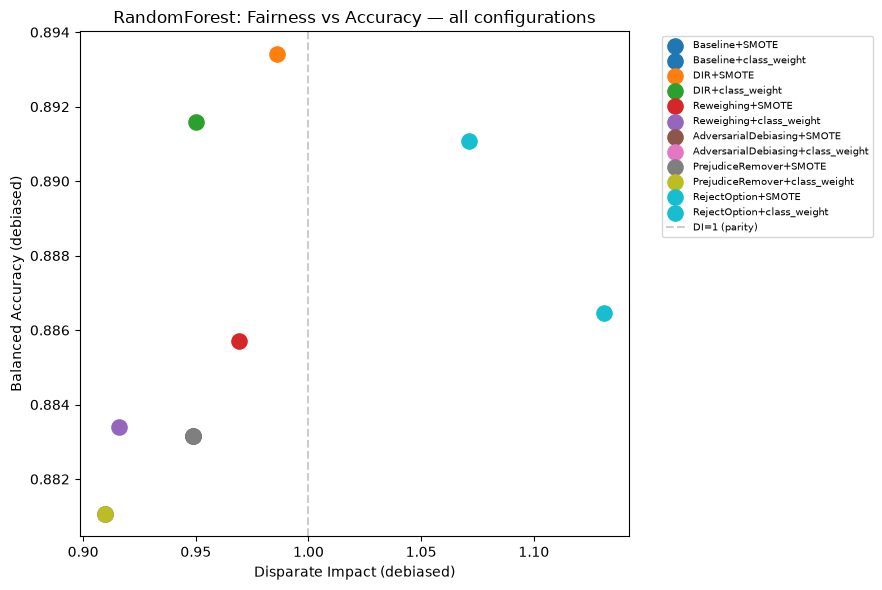

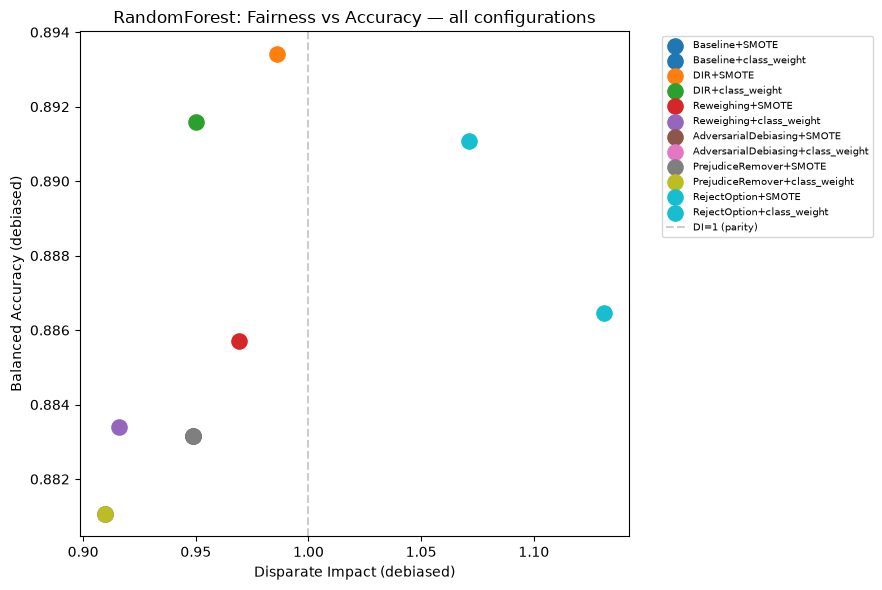

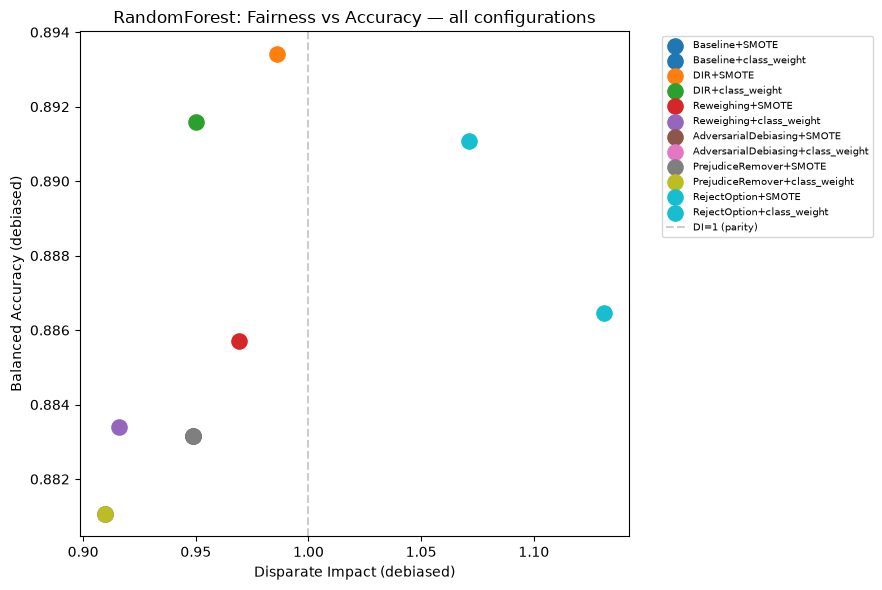

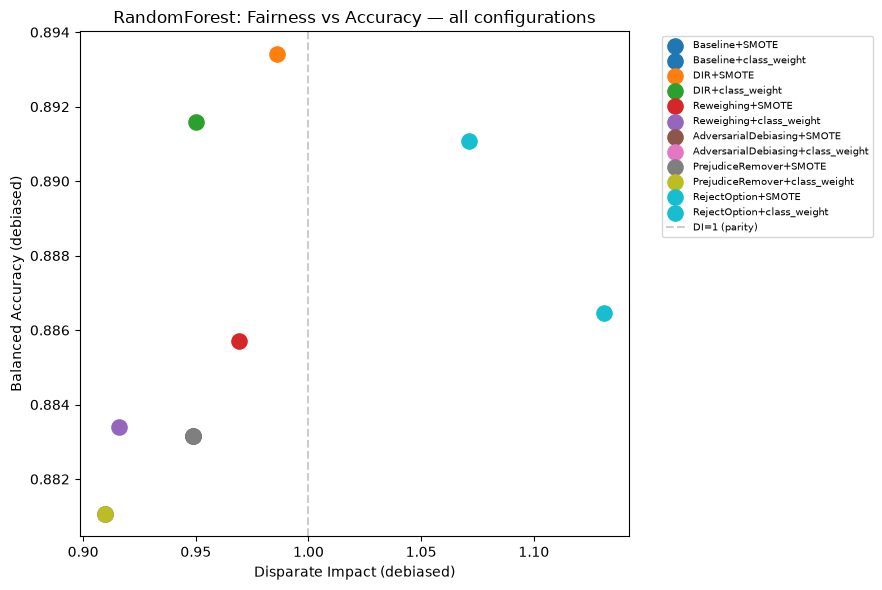

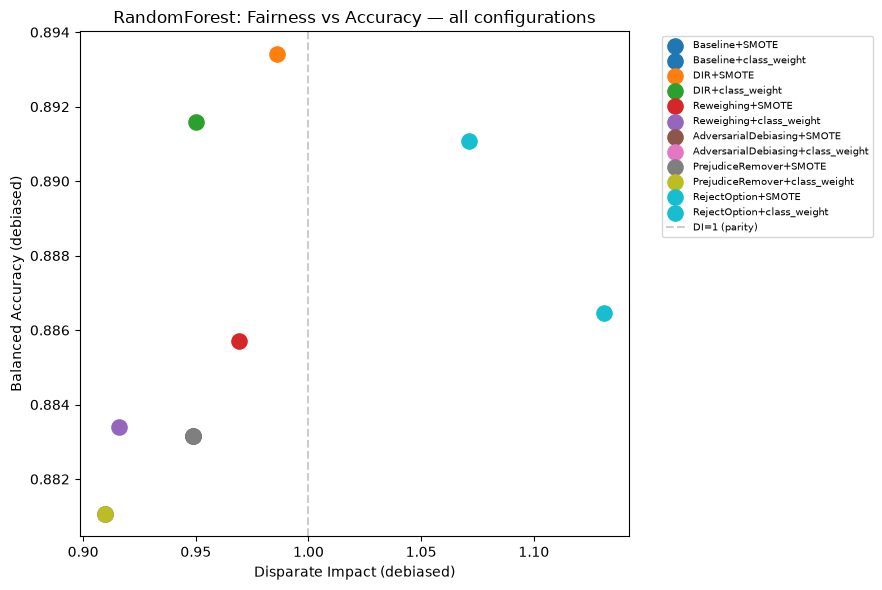

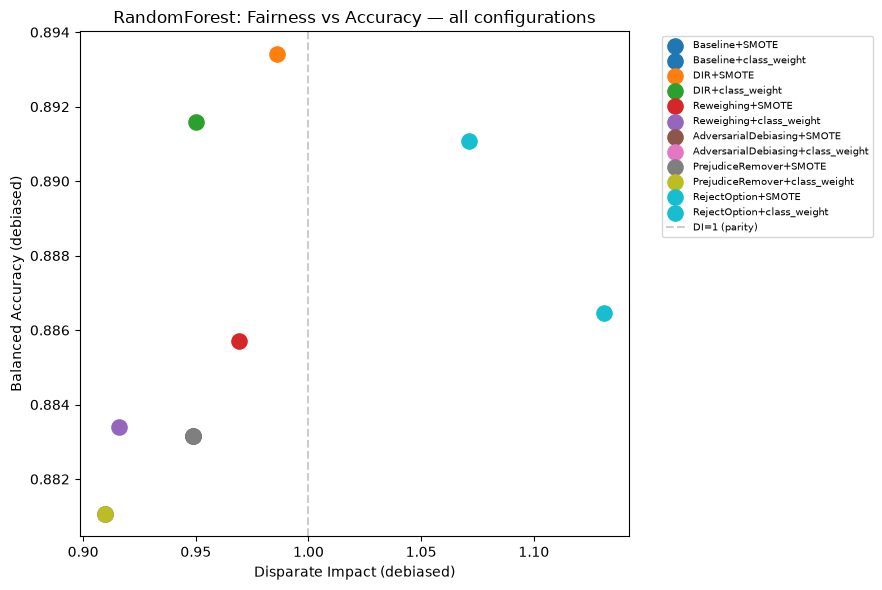

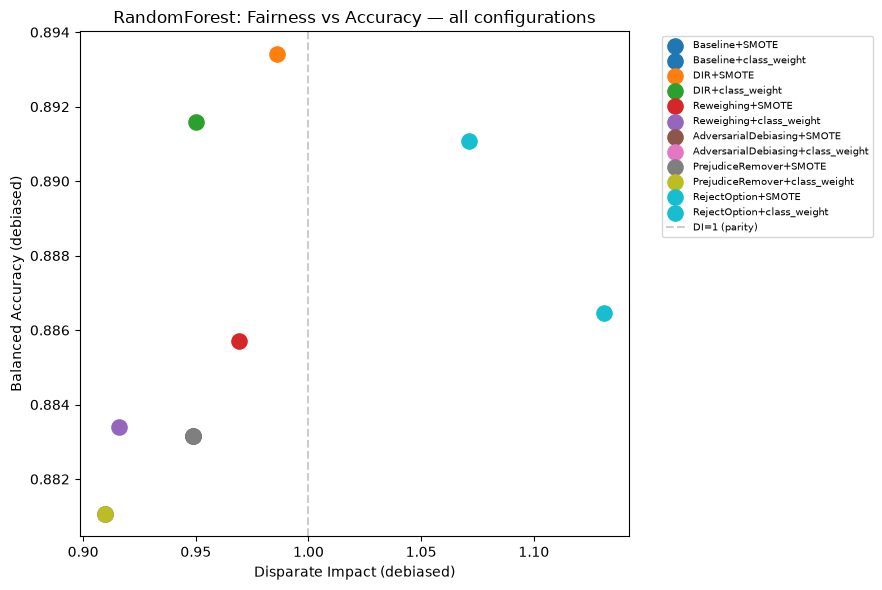

In [42]:
%matplotlib inline
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10(np.linspace(0, 1, len(configs)))
for (d, i, _), c in zip(configs, colors):
    row = df_rf[(df_rf['Debiasing'] == d) & (df_rf['Imbalance'] == i)].iloc[0]
    ax.scatter(row['DI (deb)'], row['BA (deb)'], s=120, c=[c], label=f'{d}+{i}')
ax.axvline(1.0, color='gray', ls='--', alpha=0.4, label='DI=1 (parity)')
ax.set_xlabel('Disparate Impact (debiased)')
ax.set_ylabel('Balanced Accuracy (debiased)')
ax.set_title('RandomForest: Fairness vs Accuracy — all configurations')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=7)
plt.tight_layout()